Dataset Loaded Successfully!
Shape: 200 rows, 4 columns


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

--- Missing Values ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000



Target variable detected: Sales


,Model,MAE,RMSE,R2
0,Linear Regression,1.274826,1.705215,0.905901
1,Random Forest,0.914075,1.182847,0.954722
2,Gradient Boosting,0.859828,1.139713,0.957964



Best Model: Gradient Boosting


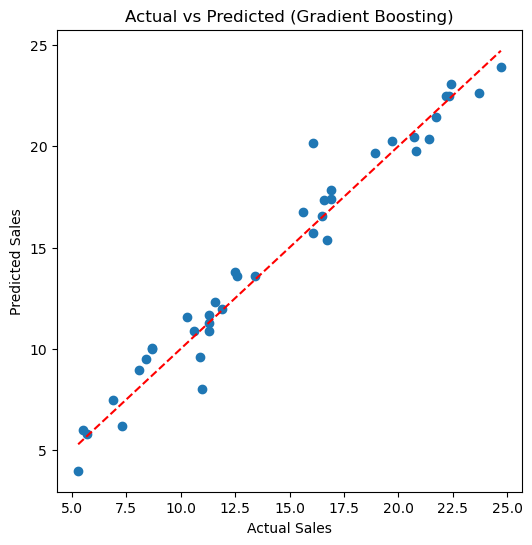

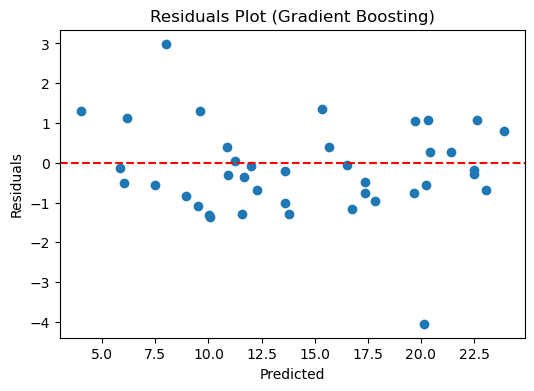

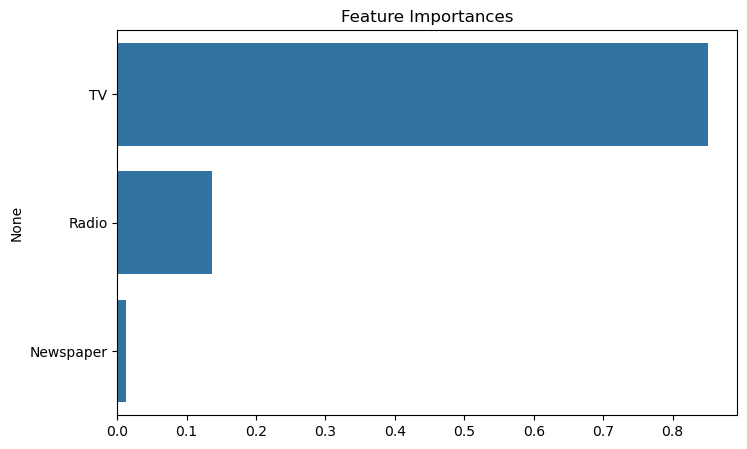


Model saved as 'sales_model_pipeline.pkl'

Example Prediction:
Input features:
       TV  Radio  Newspaper
95  163.3   31.6       52.9
Predicted Sales: 17.39


In [3]:
# ===============================================
# SALES PREDICTION USING MACHINE LEARNING IN PYTHON
# ===============================================

# ---- STEP 1: Import Libraries ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import joblib

# ---- STEP 2: Load Dataset ----
# Replace filename with your own CSV file path
df = pd.read_csv("advertising.csv")

print("Dataset Loaded Successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

# ---- STEP 3: Data Overview ----
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isna().sum())

# ---- STEP 4: Summary Statistics ----
display(df.describe())

# ---- STEP 5: Detect Target Column Automatically ----
possible_targets = [c for c in df.columns if 'sale' in c.lower()]
if possible_targets:
    target_col = possible_targets[0]
else:
    target_col = df.columns[-1]  # fallback
print(f"\nTarget variable detected: {target_col}")

# ---- STEP 6: Prepare Data ----
numeric_df = df.select_dtypes(include=[np.number])
imputer = SimpleImputer(strategy="median")
numeric_df = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)

X = numeric_df.drop(columns=[target_col])
y = numeric_df[target_col]

# ---- STEP 7: Split Dataset ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- STEP 8: Scale Features ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- STEP 9: Train Models ----
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = []
for name, model in models.items():
    if name == "Random Forest":
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
display(results_df)

# ---- STEP 10: Select Best Model ----
best_model_name = results_df.loc[results_df["RMSE"].idxmin(), "Model"]
print(f"\nBest Model: {best_model_name}")

best_model = models[best_model_name]
if best_model_name == "Random Forest":
    preds_best = best_model.predict(X_test)
else:
    preds_best = best_model.predict(X_test_scaled)

# ---- STEP 11: Visualization ----
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# Residuals
residuals = y_test - preds_best
plt.figure(figsize=(6,4))
plt.scatter(preds_best, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Residuals Plot ({best_model_name})")
plt.show()

# Feature Importances (if available)
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title("Feature Importances")
    plt.show()

# ---- STEP 12: Save Model ----
pipeline = {
    "model_name": best_model_name,
    "model": best_model,
    "scaler": scaler,
    "features": list(X.columns),
    "target": target_col
}

joblib.dump(pipeline, "sales_model_pipeline.pkl")
print("\nModel saved as 'sales_model_pipeline.pkl'")

# Example new input (replace values with real ones)
sample_input = X_test.iloc[[0]]  # just using first test row
if best_model_name == "Random Forest":
    sample_pred = best_model.predict(sample_input)[0]
else:
    sample_pred = best_model.predict(scaler.transform(sample_input))[0]

print("\nExample Prediction:")
print(f"Input features:\n{sample_input}")
print(f"Predicted Sales: {sample_pred:.2f}")
